In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [13]:
!unzip "archive (3).zip"

Archive:  archive (3).zip
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_dataset/no/27 no.jpg  
  inflating: brain_tumor_dataset/no/28 no.jpg  
  inflating: b

In [14]:
img_size = 224
batch_size = 32

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [16]:
train_generator = train_datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [17]:
val_generator = train_datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 50 images belonging to 2 classes.


In [18]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(2,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 902ms/step - accuracy: 0.6552 - loss: 0.8073 - val_accuracy: 0.7600 - val_loss: 0.5325
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.8227 - loss: 0.4759 - val_accuracy: 0.7400 - val_loss: 0.5116
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.8522 - loss: 0.3779 - val_accuracy: 0.7400 - val_loss: 0.5222
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8768 - loss: 0.2886 - val_accuracy: 0.8200 - val_loss: 0.4506
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9310 - loss: 0.1814 - val_accuracy: 0.7800 - val_loss: 0.5771
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9310 - loss: 0.1314 - val_accuracy: 0.9000 - val_loss: 0.4020
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9754 - loss: 0.0888 - val_accuracy: 0.8400 - val_loss: 0.5383
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9901 - loss: 0.0390 - val_accuracy: 0.8200 - val_loss: 0.7

In [22]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:",accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8600 - loss: 0.8805 
Validation Accuracy: 0.8600000143051147


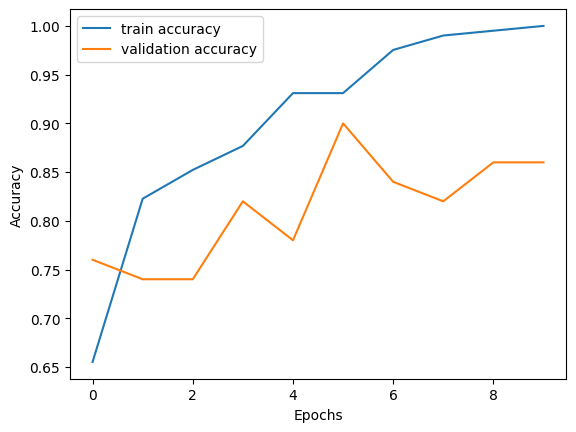

In [23]:
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()